🔹 Step 1: Install Required Libraries

In [1]:
pip install torch transformers datasets matplotlib tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔹 Step 2: Import Required Libraries

In [2]:
import torch
import math
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset
from torch.optim import AdamW


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


🔹 Step 3: Load a Pre-trained GPT-2 Model

In [4]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

🔹 Step 4: Load and Preprocess the Dataset

In [5]:
dataset = load_dataset("wikipedia", "20220301.en", split="train[:1%]")
print(dataset)


README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

wikipedia.py:   0%|          | 0.00/36.7k [00:00<?, ?B/s]

train-00000-of-00041.parquet:   0%|          | 0.00/1.04G [00:00<?, ?B/s]

train-00001-of-00041.parquet:   0%|          | 0.00/705M [00:00<?, ?B/s]

train-00002-of-00041.parquet:   0%|          | 0.00/558M [00:00<?, ?B/s]

...

train-00038-of-00041.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

train-00039-of-00041.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

train-00040-of-00041.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6458670 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 64587
})


In [6]:
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id


In [7]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format(type="torch", columns=["input_ids"])


Map:   0%|          | 0/64587 [00:00<?, ? examples/s]

In [8]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


In [9]:
split_dataset = dataset.train_test_split(test_size=0.1)  # 90% train, 10% eval
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]


🔹 Step 5: Define Training Arguments with Hyperparameter Tuning

In [10]:
from transformers import TrainerCallback

class LossLoggerCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and state.global_step % 500 == 0:
            print(f"Step {state.global_step}: Loss = {logs['loss']:.4f}")

In [11]:
training_args = TrainingArguments(
    output_dir="./gpt2_finetuned",
    per_device_train_batch_size=4,  # Adjust for GPU
    per_device_eval_batch_size=4,
    num_train_epochs=1,  # Adjusted for better fine-tuning
    learning_rate=3e-5,  # Tuned for better performance
    weight_decay=0.01,
    logging_steps=100,
    evaluation_strategy="epoch",
    save_total_limit=2,
    save_steps=500,
    dataloader_num_workers=4,
    fp16=torch.cuda.is_available(),  # Use FP16 if GPU is available
    gradient_accumulation_steps=2,  # Accumulate gradients for better performance
    max_grad_norm=1.0,  # **Gradient Clipping** to prevent exploding gradients
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


🔹 Step 6: Define Optimizer (AdamW) & Trainer

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,# **Provide eval dataset to avoid error**
    callbacks=[LossLoggerCallback()],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    optimizers=(AdamW(model.parameters(), lr=3e-5), None)
)


##Start fine-tuning.

In [13]:
trainer.train()


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nakullimbani (nakullimbani-srm-institute-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Step 500: Loss = 2.8267
Step 1000: Loss = 2.7125
Step 1500: Loss = 2.6860
Step 2000: Loss = 2.7301
Step 2500: Loss = 2.6773
Step 3000: Loss = 2.6724
Step 3500: Loss = 2.6859
Step 4000: Loss = 2.6884
Step 4500: Loss = 2.7102
Step 5000: Loss = 2.6785
Step 5500: Loss = 2.6713
Step 6000: Loss = 2.6206
Step 6500: Loss = 2.6573
Step 7000: Loss = 2.6482


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Step 7500: Loss = 2.6213
Step 8000: Loss = 2.5546
Step 8500: Loss = 2.5990
Step 9000: Loss = 2.5791
Step 9500: Loss = 2.5880
Step 10000: Loss = 2.6558
Step 10500: Loss = 2.5795
Step 11000: Loss = 2.5456
Step 11500: Loss = 2.5876
Step 12000: Loss = 2.6341
Step 12500: Loss = 2.5806
Step 13000: Loss = 2.6008
Step 13500: Loss = 2.6673
Step 14000: Loss = 2.6168
Step 14500: Loss = 2.6242


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


TrainOutput(global_step=14532, training_loss=2.6576462737003896, metrics={'train_runtime': 9084.9982, 'train_samples_per_second': 12.796, 'train_steps_per_second': 1.6, 'total_flos': 3.0376766472192e+16, 'train_loss': 2.6576462737003896, 'epoch': 2.0})

##Save The Model

In [14]:
model.save_pretrained("./gpt2_finetuned")
tokenizer.save_pretrained("./gpt2_finetuned")


('./gpt2_finetuned/tokenizer_config.json',
 './gpt2_finetuned/special_tokens_map.json',
 './gpt2_finetuned/vocab.json',
 './gpt2_finetuned/merges.txt',
 './gpt2_finetuned/added_tokens.json')

In [15]:
sample_text = "The future of AI is"
input_ids = tokenizer.encode(sample_text, return_tensors="pt").to(device)
output = model.generate(input_ids, max_length=100, num_return_sequences=1)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print("Generated Text:", generated_text)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated Text: The future of AI is uncertain. The most likely future is the emergence of artificial intelligence, which will be able to solve many problems, including human-induced cognitive problems, and will be able to solve many other problems.

AI is a field that is currently undergoing rapid technological change. It is currently being studied by many fields, including computer science, artificial intelligence, artificial intelligence, and artificial intelligence.

AI is a field that is currently undergoing rapid technological change. It is currently being studied


🔹 Step 7: Evaluate Model Performance

1️⃣ Loss Plot Before and After Fine-Tuning

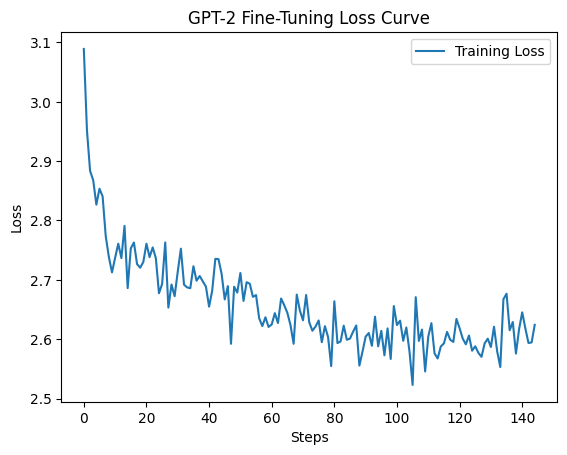

In [16]:
training_loss = trainer.state.log_history
loss_values = [entry["loss"] for entry in training_loss if "loss" in entry]

plt.plot(loss_values, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("GPT-2 Fine-Tuning Loss Curve")
plt.show()


2️⃣ Calculate Perplexity (Lower is Better)

In [17]:
def calculate_perplexity(loss):
    return math.exp(loss)

final_loss = loss_values[-1]  # Last recorded loss
perplexity = calculate_perplexity(final_loss)
print(f"Final Perplexity: {perplexity}")


Final Perplexity: 13.793534943004227


🔹 Step 8: Generate Text Before & After Fine-Tuning

In [18]:
def generate_text(prompt, model, tokenizer):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    output = model.generate(input_ids, max_length=100, num_return_sequences=1)
    return tokenizer.decode(output[0], skip_special_tokens=True)

sample_text = "The future of AI is"
print("Before Fine-Tuning:", generate_text(sample_text, model, tokenizer))

# Load Fine-Tuned Model
model = GPT2LMHeadModel.from_pretrained("./gpt2_finetuned").to(device)
print("After Fine-Tuning:", generate_text(sample_text, model, tokenizer))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Before Fine-Tuning: The future of AI is uncertain. The most likely future is the emergence of artificial intelligence, which will be able to solve many problems, including human-induced cognitive problems, and will be able to solve many other problems.

AI is a field that is currently undergoing rapid technological change. It is currently being studied by many fields, including computer science, artificial intelligence, artificial intelligence, and artificial intelligence.

AI is a field that is currently undergoing rapid technological change. It is currently being studied


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


After Fine-Tuning: The future of AI is uncertain. The most likely future is the emergence of artificial intelligence, which will be able to solve many problems, including human-induced cognitive problems, and will be able to solve many other problems.

AI is a field that is currently undergoing rapid technological change. It is currently being studied by many fields, including computer science, artificial intelligence, artificial intelligence, and artificial intelligence.

AI is a field that is currently undergoing rapid technological change. It is currently being studied


In [20]:
# prompt: save the model to local directory of machine

from google.colab import files
files.download("./gpt2_finetuned")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# prompt: save and download the model to local directory of machine

from google.colab import files
!zip -r gpt2_finetuned.zip ./gpt2_finetuned
files.download('gpt2_finetuned.zip')


  adding: gpt2_finetuned/ (stored 0%)
  adding: gpt2_finetuned/runs/ (stored 0%)
  adding: gpt2_finetuned/runs/Mar08_14-22-09_64f3d758dfdf/ (stored 0%)
  adding: gpt2_finetuned/runs/Mar08_14-22-09_64f3d758dfdf/events.out.tfevents.1741443733.64f3d758dfdf.326.0 (deflated 68%)
  adding: gpt2_finetuned/config.json (deflated 52%)
  adding: gpt2_finetuned/checkpoint-14500/ (stored 0%)
  adding: gpt2_finetuned/checkpoint-14500/trainer_state.json (deflated 78%)
  adding: gpt2_finetuned/checkpoint-14500/config.json (deflated 52%)
  adding: gpt2_finetuned/checkpoint-14500/training_args.bin (deflated 51%)
  adding: gpt2_finetuned/checkpoint-14500/optimizer.pt (deflated 8%)
  adding: gpt2_finetuned/checkpoint-14500/generation_config.json (deflated 24%)
  adding: gpt2_finetuned/checkpoint-14500/rng_state.pth (deflated 25%)
  adding: gpt2_finetuned/checkpoint-14500/scheduler.pt (deflated 54%)
  adding: gpt2_finetuned/checkpoint-14500/model.safetensors (deflated 7%)
  adding: gpt2_finetuned/checkpoin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import wandb

# Initialize the WandB API
api = wandb.Api()

# Access the specific run using the correct path
run = api.run("/nakullimbani-srm-institute-of-science-and-technology/huggingface/runs/9rasluaa")

# Access run details
print(run.summary)  # Example: print run summary


{'_runtime': 8525.868215102, '_step': 147, '_timestamp': 1741452818.2684972, '_wandb': {'runtime': 8525}, 'eval/loss': 2.5511350631713867, 'eval/runtime': 136.1005, 'eval/samples_per_second': 47.458, 'eval/steps_per_second': 11.866, 'total_flos': 30376766472192000, 'train/epoch': 2, 'train/global_step': 14532, 'train/grad_norm': 1.265838623046875, 'train/learning_rate': 7.844756399669695e-08, 'train/loss': 2.6242, 'train_loss': 2.6576462737003896, 'train_runtime': 9084.9982, 'train_samples_per_second': 12.796, 'train_steps_per_second': 1.6}


In [25]:

print(run.history())

     _step     _runtime  train/loss train/grad_norm  train/learning_rate  \
0        0    58.578668      3.0891        3.538035         2.979562e-05   
1        1   108.069658      2.9519         2.75423         2.958918e-05   
2        2   157.845224      2.8835        2.450564         2.938274e-05   
3        3   207.453398      2.8678         2.46605         2.917630e-05   
4        4   257.140126      2.8267        2.031511         2.896986e-05   
..     ...          ...         ...             ...                  ...   
143    143  8203.565116      2.5936        1.296131         4.913295e-07   
144    144  8253.164292      2.5945        1.323662         2.848885e-07   
145    145  8302.828879      2.6242        1.265839         7.844756e-08   
146    146  8525.828284         NaN             NaN                  NaN   
147    147  8525.868215         NaN             NaN                  NaN   

     train/epoch    _timestamp  train/global_step  eval/loss  \
0       0.013763  1.741

In [27]:
# Accessing summary (metrics and statistics)
print(run.summary)

# Accessing config (hyperparameters)
print(run.config)

{'_runtime': 8525.868215102, '_step': 147, '_timestamp': 1741452818.2684972, '_wandb': {'runtime': 8525}, 'eval/loss': 2.5511350631713867, 'eval/runtime': 136.1005, 'eval/samples_per_second': 47.458, 'eval/steps_per_second': 11.866, 'total_flos': 30376766472192000, 'train/epoch': 2, 'train/global_step': 14532, 'train/grad_norm': 1.265838623046875, 'train/learning_rate': 7.844756399669695e-08, 'train/loss': 2.6242, 'train_loss': 2.6576462737003896, 'train_runtime': 9084.9982, 'train_samples_per_second': 12.796, 'train_steps_per_second': 1.6}
{'bf16': False, 'fp16': True, 'fsdp': [], 'seed': 42, 'tf32': None, 'debug': [], 'n_ctx': 1024, 'optim': 'adamw_torch', 'top_k': 50, 'top_p': 1, 'n_embd': 768, 'n_head': 12, 'prefix': None, 'do_eval': True, 'n_inner': None, 'n_layer': 12, 'no_cuda': False, 'use_cpu': False, 'do_train': False, 'id2label': {'0': 'LABEL_0', '1': 'LABEL_1'}, 'label2id': {'LABEL_0': 0, 'LABEL_1': 1}, 'run_name': './gpt2_finetuned', 'use_ipex': False, 'adafactor': False, 

In [30]:
# prompt: load the model

import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel


# Load the fine-tuned model and tokenizer
model = GPT2LMHeadModel.from_pretrained("./gpt2_finetuned").to(device)
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_finetuned")


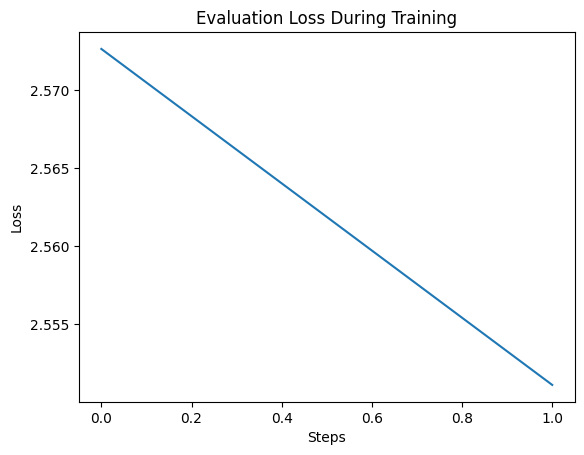

In [29]:
import matplotlib.pyplot as plt

# Extract evaluation losses from trainer logs
eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Plot the evaluation loss graph
plt.plot(eval_losses)
plt.title("Evaluation Loss During Training")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()
